# 🟠 Lesson 18 — Plotly

**Level: Advanced** · Interactive charts — hover over every sample, rotate 3-D drillholes, share plots as standalone HTML.

*Part of the companion package for [python_for_geologists](https://github.com/kevinalexandr19/python_for_geologists) by Kevin Alexander Gomez.*

In [1]:
import plotly.express as px
import plotly.io as pio
import pandas as pd
from pathlib import Path
import plotly
print("plotly", plotly.__version__)

# static PNG rendering so outputs are stored in the notebook;
# delete this line to get fully interactive plots in Jupyter.
pio.renderers.default = "png"

DATA = Path("..") / "data"
rocks = pd.read_csv(DATA / "rocks.csv")
assay = pd.read_csv(DATA / "assay.csv")

plotly 6.3.0


## 1. Interactive scatter — Harker diagram with hover info

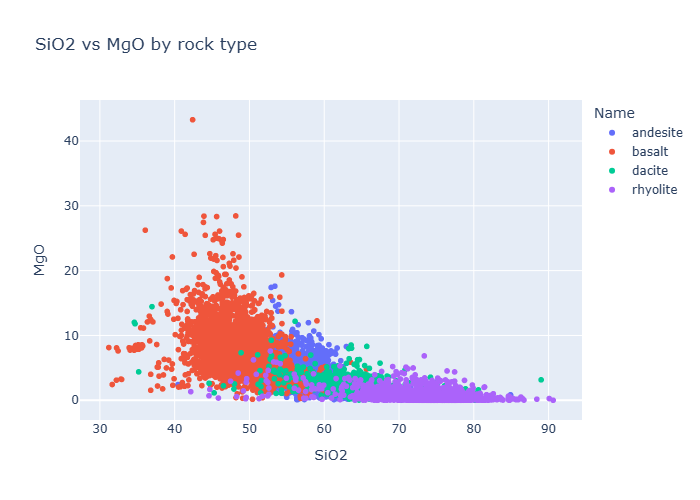

In [2]:
fig = px.scatter(rocks, x="SiO2", y="MgO", color="Name",
                 hover_data=["K2O", "TiO2"],
                 title="SiO2 vs MgO by rock type",
                 width=750, height=500)
fig.show()

## 2. Box plots — grade by drillhole

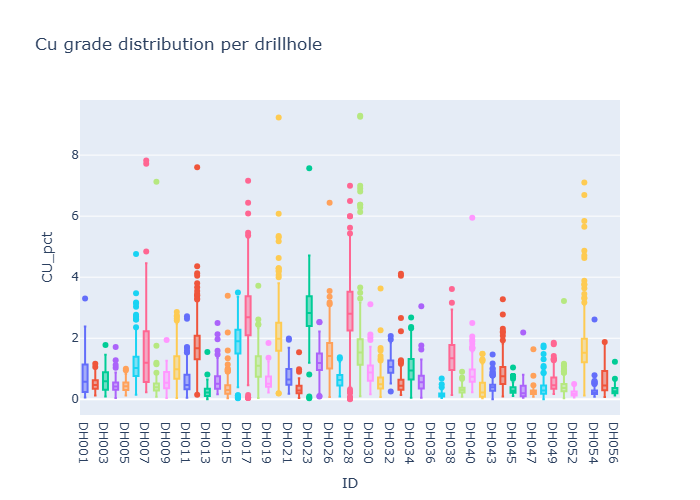

In [3]:
fig = px.box(assay, x="ID", y="CU_pct", color="ID",
             title="Cu grade distribution per drillhole",
             width=750, height=450)
fig.update_layout(showlegend=False)
fig.show()

## 3. 3-D scatter — pseudo drillhole view
We fake collar positions to show the 3-D API (real projects use surveyed x, y, z).

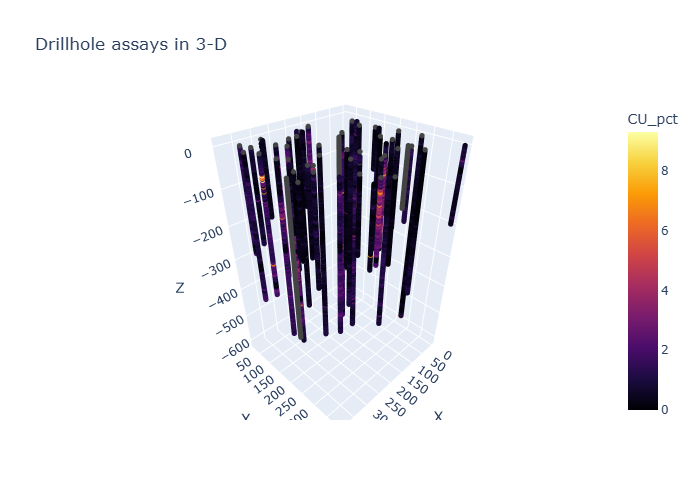

In [4]:
import numpy as np
rng = np.random.default_rng(3)
collars = {dh: (rng.uniform(0, 400), rng.uniform(0, 400)) for dh in assay["ID"].unique()}
assay["X"] = assay["ID"].map(lambda d: collars[d][0])
assay["Y"] = assay["ID"].map(lambda d: collars[d][1])
assay["Z"] = -(assay["FROM"] + assay["TO"]) / 2          # depth downwards

fig = px.scatter_3d(assay, x="X", y="Y", z="Z", color="CU_pct",
                    color_continuous_scale="Inferno", hover_data=["ID"],
                    title="Drillhole assays in 3-D", width=750, height=600)
fig.update_traces(marker_size=3)
fig.show()

## 4. Faceted histograms — one subplot per element, zero boilerplate

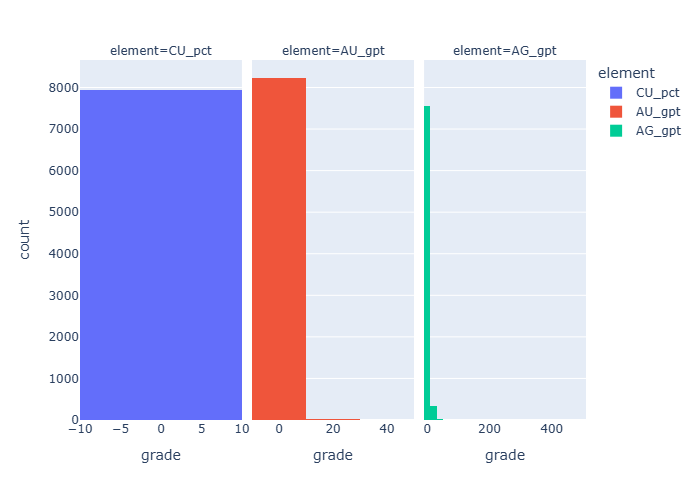

In [5]:
long = assay.melt(value_vars=["CU_pct", "AU_gpt", "AG_gpt"],
                  var_name="element", value_name="grade").dropna()
fig = px.histogram(long, x="grade", facet_col="element", color="element",
                   nbins=30, width=900, height=350)
fig.update_xaxes(matches=None)          # independent x scales
fig.show()

## 5. Export a shareable interactive HTML file

In [6]:
out = Path("outputs"); out.mkdir(exist_ok=True)
fig.write_html(out / "assay_histograms.html", include_plotlyjs="cdn")
print("open in any browser ->", out / "assay_histograms.html")

open in any browser -> outputs\assay_histograms.html


### ✏️ Try it
1. Make a `px.scatter_ternary` of (CaO, Na2O + K2O, FeOT) — a classic AFM-style plot.
2. Animate the Harker diagram by rock type with `animation_frame='Name'`.

📚 Docs: https://plotly.com/python/